In [288]:
import numpy as np 
import math
class Value:
    def __init__(self, data, _children = (), _op='',label =''):
        self.data = data 
        self.grad = 0 
        self._prev = _children
        self._op = _op 
        self.label = label
        self._backward = lambda: None



    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, {self,other},'+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out 

    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.data * other.data, {self,other},'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 
        out._backward = _backward

            
        return out 

    def tanh(self):
        x = self.data 
        t = (math.exp(2*x)-1 ) / (math.exp(2*x) + 1 )
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
    # Subtraction
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)

# Negation
    def __neg__(self):
        return self * -1

    # Power (only for scalar exponents)
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supports int/float powers"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

            

    
a  = Value(2.0,label='a')
b = Value(3.0, label='b')
c = Value(-2.0, label='c')
a + b # a.__add__(b) or a + b 
a * b # or  a.__mul__(b)
d = a * b + c  # (a.__mul__(b)).__add__(c)
d.label = 'd'
e = d * a * c 
f = Value(-2,label='f')
L =  d * f
L.label = 'L'



In [289]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s  |data %.4f  | grad %.2f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

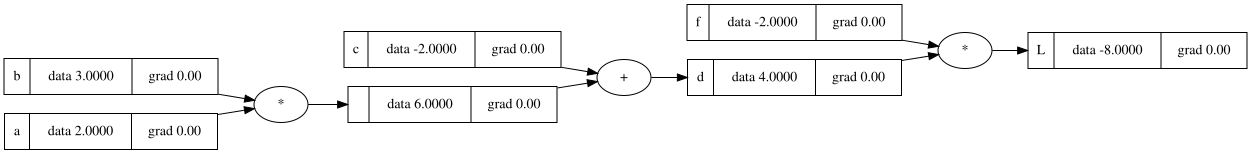

In [290]:
draw_dot(L)

In [291]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')

w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')

b = Value(6.7,label=2)

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'


x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + b ; n.label = 'n'
o = n.tanh() ; o.label = 'o'

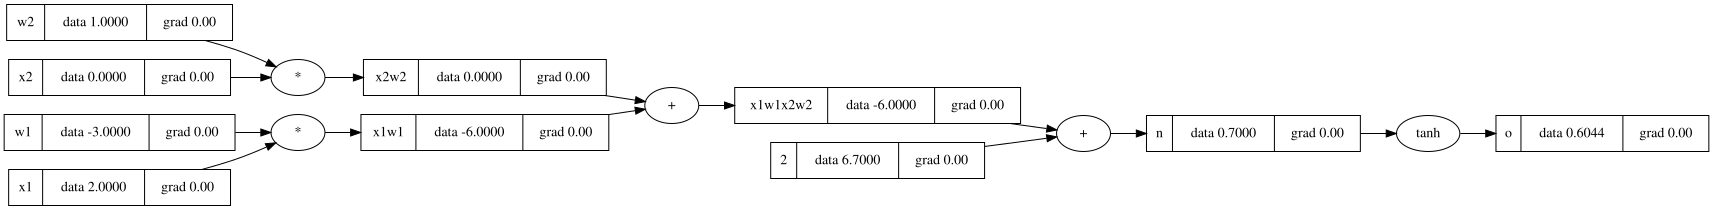

In [292]:
draw_dot(o)

In [293]:
o.backward()

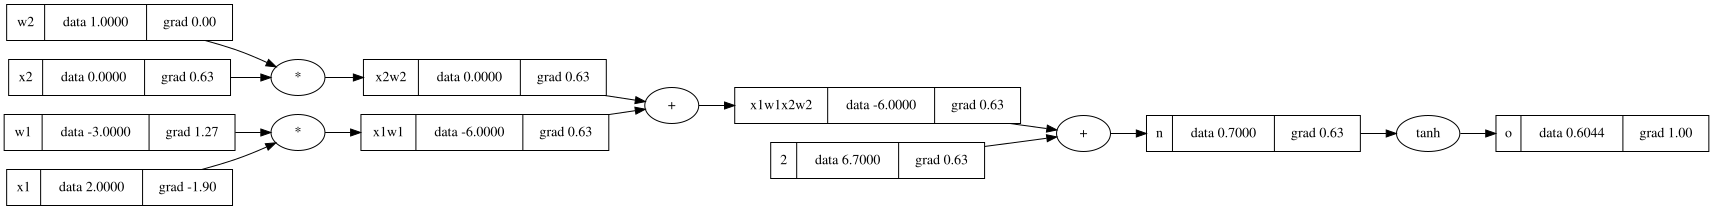

In [294]:
draw_dot(o)

In [295]:
import random
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1))for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        x = [xi if isinstance(xi, Value) else Value(xi) for xi in x]
        act = sum((wi * xi for wi, xi in zip(self.w, x)), Value(0)) + self.b
        out = act.tanh()
        return out
    

class Layer:

    def __init(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]


    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs



class MLP:

    def __init__(self,nin,nouts):
        sx = [nin] + nouts
        self.layers = [Layer(sx[i], sx[i+1]) for i in range(len(nouts))]


    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x




x = [2.0,3.0]
n = Neuron(2)

        

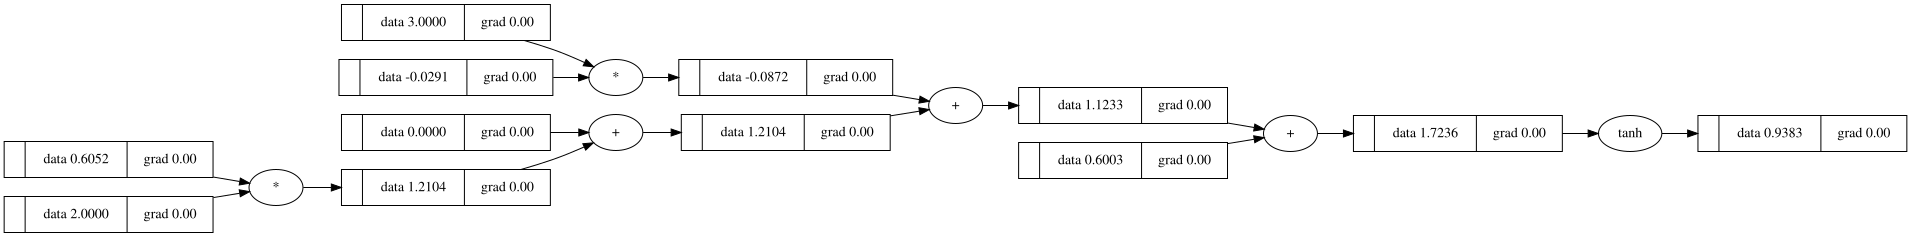

In [296]:
draw_dot(n(x))


In [309]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0,-1.0,-1.0,1.0] # targetss


ys = [Value(y) for y in ys]
y_pred = [n(x) for x in xs]


In [308]:
# Assuming y_pred and ys are lists of Value objects of the same length
loss = Value(0)
for yp, yt in zip(y_pred, ys):
    loss += (yp - yt) ** 2


In [310]:
loss.backward()
